# EDA — Lenta.ru Dataset

Исследовательский анализ данных: 10 000 статей из Lenta.ru, загруженных в PostgreSQL.

**Цель:** понять структуру датасета перед тематическим моделированием.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

load_dotenv(dotenv_path='../.env')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
conn = psycopg2.connect(
    dbname=os.getenv('DB_NAME'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST', 'localhost'),
    port=os.getenv('DB_PORT', '5432'),
)
print('Подключение установлено.')

Подключение установлено.


## 1. Количество документов по рубрикам

In [3]:
sql_topics = """
SELECT t.name AS topic, COUNT(*) AS docs
FROM topics t
JOIN raw_documents d ON t.id = d.topic_id
GROUP BY t.name
ORDER BY docs DESC;
"""
df_topics = pd.read_sql(sql_topics, conn)
print(df_topics.to_string(index=False))

            topic  docs
           Россия  1531
              Мир  1343
            Спорт  1040
        Экономика   978
      Бывший СССР   751
   Интернет и СМИ   701
         Культура   688
         Из жизни   663
  Наука и техника   645
Силовые структуры   590
         Ценности   383
      Путешествия   318
              Дом   287
   69-я параллель    78
           Бизнес     1


/tmp/claude-501/ipykernel_10035/1646255950.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_topics = pd.read_sql(sql_topics, conn)


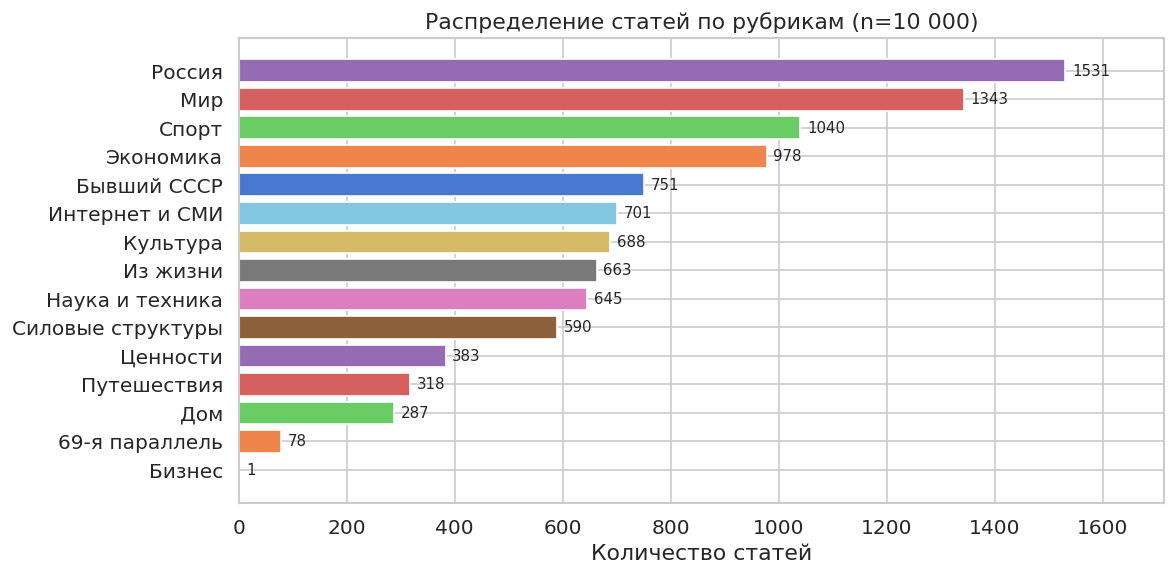

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_topics['topic'][::-1], df_topics['docs'][::-1], color=sns.color_palette('muted', len(df_topics)))
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Количество статей')
ax.set_title('Распределение статей по рубрикам (n=10 000)')
ax.set_xlim(0, df_topics['docs'].max() * 1.12)
plt.tight_layout()
plt.savefig('../reports/01_docs_per_topic.png', bbox_inches='tight')
plt.show()

## 2. Средняя, минимальная и максимальная длина статьи по рубрикам

In [5]:
sql_lengths = """
SELECT t.name AS topic,
       ROUND(AVG(word_count), 1) AS avg_words,
       MIN(word_count)           AS min_words,
       MAX(word_count)           AS max_words
FROM topics t
JOIN raw_documents d ON t.id = d.topic_id
GROUP BY t.name
ORDER BY avg_words DESC;
"""
df_lengths = pd.read_sql(sql_lengths, conn)
print(df_lengths.to_string(index=False))

            topic  avg_words  min_words  max_words
      Бывший СССР      209.7         42        584
        Экономика      205.0         61        922
              Дом      204.6         86        347
  Наука и техника      191.5         47        591
              Мир      187.9         58        472
   Интернет и СМИ      187.9         56        557
         Из жизни      184.8         51        439
Силовые структуры      181.6         62        519
           Россия      170.5         40        746
         Ценности      168.7         88        686
      Путешествия      163.4         70        329
   69-я параллель      158.7         66        314
            Спорт      146.2         42        425
         Культура      145.6         47        686
           Бизнес      110.0        110        110


/tmp/claude-501/ipykernel_10035/4151139791.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lengths = pd.read_sql(sql_lengths, conn)


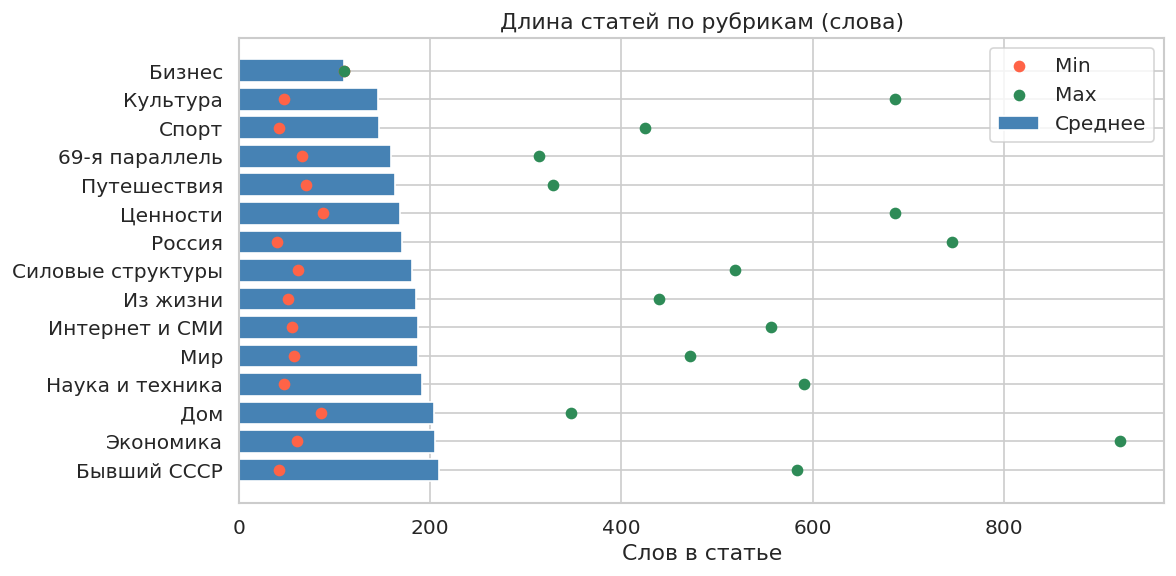

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(df_lengths))
labels = df_lengths['topic'].tolist()
ax.barh(y, df_lengths['avg_words'], color='steelblue', label='Среднее')
ax.scatter(df_lengths['min_words'], y, color='tomato', zorder=5, label='Min')
ax.scatter(df_lengths['max_words'], y, color='seagreen', zorder=5, label='Max')
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Слов в статье')
ax.set_title('Длина статей по рубрикам (слова)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/02_word_count_per_topic.png', bbox_inches='tight')
plt.show()

## 3. Глобальное распределение длины статей

In [7]:
sql_global = """
SELECT
    MIN(word_count)                                             AS global_min,
    MAX(word_count)                                             AS global_max,
    ROUND(AVG(word_count), 1)                                   AS global_avg,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY word_count)     AS median,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY word_count)    AS p25,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY word_count)    AS p75
FROM raw_documents;
"""
df_global = pd.read_sql(sql_global, conn)
print(df_global.to_string(index=False))

 global_min  global_max  global_avg  median   p25   p75
         40         922       179.7   169.0 138.0 209.0


/tmp/claude-501/ipykernel_10035/4186755789.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_global = pd.read_sql(sql_global, conn)


/tmp/claude-501/ipykernel_10035/816297916.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql("SELECT word_count FROM raw_documents;", conn)


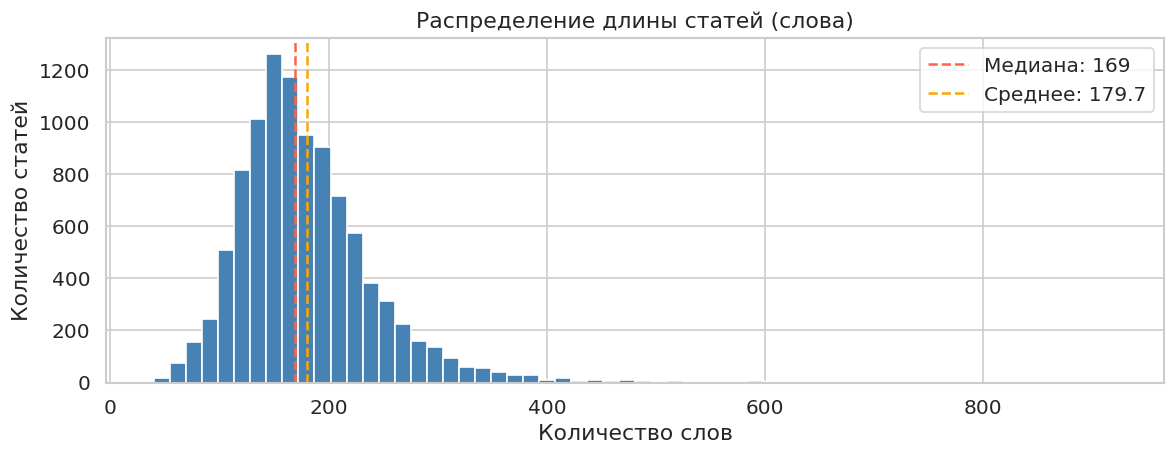

In [8]:
df_all = pd.read_sql("SELECT word_count FROM raw_documents;", conn)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_all['word_count'], bins=60, color='steelblue', edgecolor='white')
ax.axvline(df_global['median'].iloc[0], color='tomato',    linestyle='--', label=f"Медиана: {int(df_global['median'].iloc[0])}")
ax.axvline(df_global['global_avg'].iloc[0], color='orange', linestyle='--', label=f"Среднее: {df_global['global_avg'].iloc[0]}")
ax.set_xlabel('Количество слов')
ax.set_ylabel('Количество статей')
ax.set_title('Распределение длины статей (слова)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_word_count_distribution.png', bbox_inches='tight')
plt.show()

## 4. Проверка пустых текстов

In [9]:
sql_empty = """
SELECT
    COUNT(*) FILTER (WHERE body IS NULL OR TRIM(body) = '') AS empty_texts,
    COUNT(*) FILTER (WHERE title IS NULL OR TRIM(title) = '') AS empty_titles,
    COUNT(*) AS total
FROM raw_documents;
"""
df_empty = pd.read_sql(sql_empty, conn)
print(df_empty.to_string(index=False))

/tmp/claude-501/ipykernel_10035/2493837894.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_empty = pd.read_sql(sql_empty, conn)


 empty_texts  empty_titles  total
           0             0  10000


## 5. Проверка дубликатов заголовков

In [10]:
sql_dups = """
SELECT COUNT(*) AS total_docs,
       COUNT(DISTINCT title) AS unique_titles,
       COUNT(*) - COUNT(DISTINCT title) AS duplicate_titles
FROM raw_documents;
"""
df_dups = pd.read_sql(sql_dups, conn)
print(df_dups.to_string(index=False))

sql_dup_list = """
SELECT title, COUNT(*) AS cnt
FROM raw_documents
GROUP BY title HAVING COUNT(*) > 1
ORDER BY cnt DESC;
"""
df_dup_list = pd.read_sql(sql_dup_list, conn)
print('\nДублирующиеся заголовки:')
print(df_dup_list.to_string(index=False))

 total_docs  unique_titles  duplicate_titles
      10000           9995                 5

Дублирующиеся заголовки:
                                                              title  cnt
В Санкт-Петербурге пройдет конференция о меняющих жизнь технологиях    2
                        В Москве заметили бум продаж дорогого жилья    2
                   Названы районы Петербурга с самым дешевым жильем    2
                             «Спартак» упустил победу в Лиге Европы    2
                                     Названа причина аварии «Союза»    2


/tmp/claude-501/ipykernel_10035/594657691.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dups = pd.read_sql(sql_dups, conn)
/tmp/claude-501/ipykernel_10035/594657691.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dup_list = pd.read_sql(sql_dup_list, conn)


## Выводы

### Структура датасета
- **10 000 документов**, **15 рубрик**
- Датасет **несбалансирован**: «Россия» — 1531 ст., «Бизнес» — 1 ст.
- Топ-4 рубрики (Россия, Мир, Спорт, Экономика) дают **49% всех документов**

### Длина статей
- Глобальный диапазон: **40–922 слова**
- Среднее: **179.7** слов, медиана: **169** слов
- IQR: 138–209 слов — большинство статей компактны
- «Бывший СССР» и «Экономика» — самые длинные рубрики (~210 слов)
- «Спорт» и «Культура» — самые короткие (~146 слов)

### Качество данных
- Пустых текстов: **0** — данные чистые
- Пустых заголовков: **0**
- Дубликатов заголовков: **5** (каждый встречается дважды) — незначительно

### Проблемы
1. **Дисбаланс классов** — рубрика «Бизнес» (1 документ) и «69-я параллель» (78) бесполезны для LDA/NMF
2. **Нет поля `date`** в v1.0 датасета — временной анализ недоступен
3. **Рубрика «69-я параллель»** — нишевая, возможно стоит объединить с другими или исключить

In [11]:
conn.close()
print('Соединение закрыто.')

Соединение закрыто.
